In [2]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt

# part 1

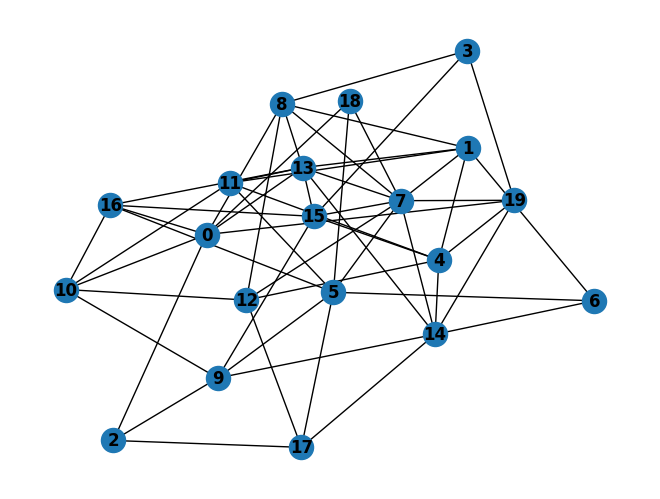

In [3]:
N = 20 # num of nodes
k = 15 # dictates prob.

def create_q_random_graph(N = 20,k = 15,Base_G = None):
  """
  we build a random adjacency matrix and form a graph from it.
  we take advantage of the uniform dist. of the np.random function.
  if the entry i,j or j,i is 1 after comparing to q, using the nx.Graph(...) to create the graph adds the edge {i,j}.
  that is because we used nx.Graph(...) and not nx.DiGraph(...).
  this is according to the definition of the prob. q given in the assignment
  """
  q = k/100 # prob
  adj_matrix = np.random.rand(N,N) < q # matrix entries that are uniformly dist. over [0,1] have a prob. q to be lower than q
  if Base_G is not None :
    M = nx.convert_matrix.to_numpy_array(Base_G)
    M_indicies = M > 0
    adj_matrix[M_indicies] = 1
    # print(adj_matrix)
  adj_matrix = np.array(adj_matrix *(np.ones((N,N)) - np.eye(N)),dtype=int) # remove diag. of adjacency matrix to prevent self loops
  G = nx.Graph(adj_matrix) # create a new graph based on the adj. matrix
  return G

# making sure that the adj_matrix is symmetric, meaning the graph is not directed
G = create_q_random_graph(N,k)
M = nx.convert_matrix.to_numpy_array(G)
# print(M-M.T)

nx.draw(G, with_labels=True, font_weight='bold')

In [4]:
def q_random_graph_q_sweep(N=20):
  precenteges_of_connected = []
  for k in range(5,100,5) :
    num_of_fully_connected = 0
    for i in range(10):
      G = create_q_random_graph(N,k)
      if nx.is_connected(G) : # this is an nx implementation of checking if the graph is connected using BFS
        num_of_fully_connected += 1
    precenteges_of_connected.append(num_of_fully_connected*10)
  return precenteges_of_connected

full explaination for random connected graphs:

https://projecteuclid.org/download/pdf_1/euclid.aoms/1177706098

$$1-P_n ≈ 1-N⋅q^{n-1} $$
where Pn is the prob. of G being connected

for a cumilative more exact form :

 $$P_1 = 1 \ : \ P_n = 1 - \sum_{i=1}^{n-1} \binom{n-1}{i-1} (1 - p)^{i(n - i)} P_i$$





In [5]:
from math import comb
N = 20
p = 0.5

def recurrence_formula(N,p):
  P = {}
  for i in range(1,N+1):
    if i == 1 :
      P[1] = 1
    else:
      P[i] = sum(P[k] * comb(N-1,k-1) * (1-p) ** (k*(N-k)) for k in range(1,i))
  return P[N]

result = recurrence_formula(N,p)
print(result)

1.907417759684551e-06


Text(0, 0.5, 'C(q)[%]')

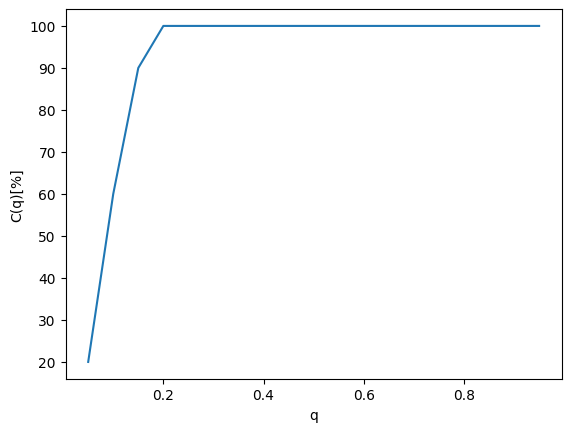

In [6]:
N = 20
precenteges_1 = q_random_graph_q_sweep(N)
plt.plot([i/100 for i in range(5,100,5)],precenteges_1)
plt.xlabel("q")
plt.ylabel("C(q)[%]")

# part two

In [7]:
def q_random_graph_N_sweep(k = 50,s = 10):
  precenteges_of_connected = []
  for N in range(5,100,5) :
    total_num_of_triangles = 0
    for i in range(s):
      G = create_q_random_graph(N,k)
      total_num_of_triangles += sum(nx.triangles(G).values())//6  # this is an nx implementation of counting the amount of triangles in G
                                                                  # it counts every triangle once from each node in the triangle so we divide by 3 ...
    precenteges_of_connected.append(total_num_of_triangles/s)
  return precenteges_of_connected

### the closed expression for the expected value of triangles :  $ \ T ∼ Bin(N,q) $
- the prob. of each edge to form is independent of the others so we take it out of the summation
- we are summing over all possible triangle combination so we are actually counting the possible groups of size $k = 3$ out of the possible $N$ nodes
- overall we get :
$$ \mathbb{E}[T] = Σ_{u \not = w \not = v \in V} P(T = \{v,u,w \} \in 2^E) = q^3 \cdot Σ_{u \not = w \not = v\in V}(1) = {n \choose 3} ⋅ q^3  \approx n^3$$

Text(0, 0.5, 't3(q)[%]')

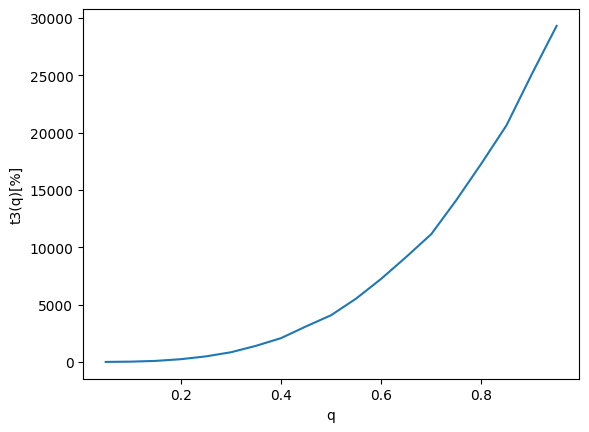

In [8]:
precenteges_2 = q_random_graph_N_sweep()
plt.plot([i/100 for i in range(5,100,5)],precenteges_2)
# plt.plot([i/100 for i in range(5,100,5)],[comb(i-1,3)*(1/8) for i in range(5,100,5)],"--")
plt.xlabel("q")
plt.ylabel("t3(q)[%]")

# part three

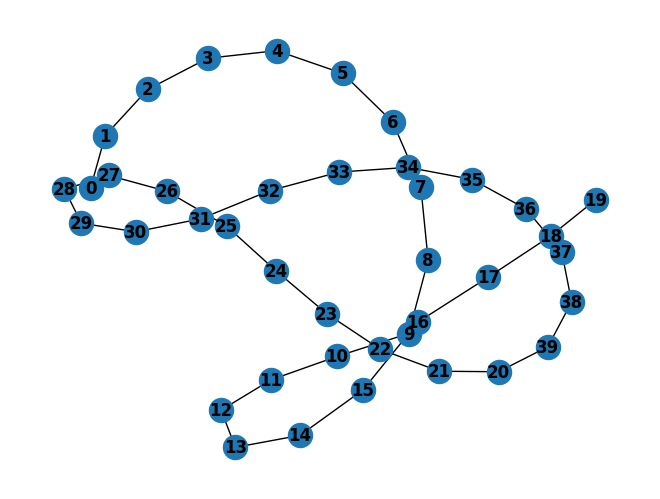

In [9]:
G1 = nx.path_graph(N) # cycle of N nodes
G2 = nx.cycle_graph(N) # cycle of N nodes
G2 = nx.relabel_nodes(G2,lambda x : x+N) # draw them with different nodes...
nx.draw(G1, with_labels=True, font_weight='bold')
nx.draw(G2, with_labels=True, font_weight='bold')

In [ ]:
M1 = nx.convert_matrix.to_numpy_array(G1)
M2 = nx.convert_matrix.to_numpy_array(G2)

G1_ = create_q_random_graph(Base_G=G1)
G2_ = create_q_random_graph(Base_G=G2)

M1_ = nx.convert_matrix.to_numpy_array(G1_)
M2_ = nx.convert_matrix.to_numpy_array(G2_)
# print(M)

eq_1 = sum(nx.eccentricity(G1_).values())/G1_.number_of_nodes()
eq_2 = sum(nx.eccentricity(G2_).values())/G2_.number_of_nodes()
print(f"eq1 = {eq_1} \neq2 = {eq_2}")

# nx.draw(G, with_labels=True, font_weight='bold')

eq1 = 2.75 
 eq2 = 2.2


In [11]:
def q_random_graph_q_sweep(N = 20 ,k = 50,s = 10,Base_G = nx.Graph()):
  if nx.is_empty(Base_G):
    Base_G.add_nodes_from([i for i in range(N)])

  average_eccentricities = []
  for k in range(5,100,5) :
    sum_of_avg_eccentricities = 0
    for i in range(s):
      G = create_q_random_graph(N,k,Base_G)
      try :
        eq = sum(nx.eccentricity(G).values())/G.number_of_nodes()
      except :
        eq = N+1
      sum_of_avg_eccentricities += eq
    average_eccentricities.append(sum_of_avg_eccentricities/s)

  return average_eccentricities
avg_ecc = q_random_graph_q_sweep()
print(f"{avg_ecc}")

[21.0, 7.284999999999999, 4.819999999999999, 2.625, 2.1, 2.0200000000000005, 2.0, 2.0, 2.0, 1.9949999999999999, 1.9949999999999999, 1.975, 1.905, 1.825, 1.735, 1.48, 1.2949999999999997, 1.18, 1.045]


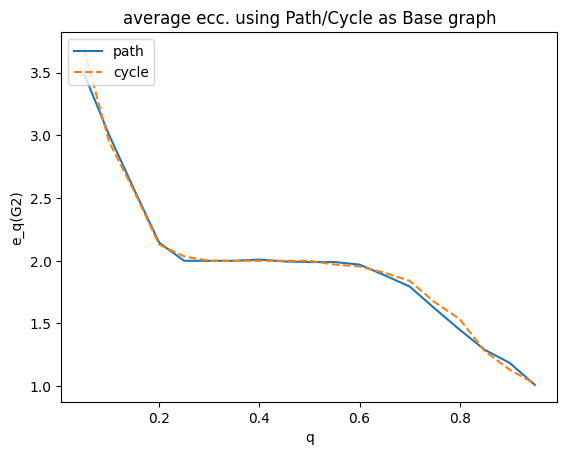

In [12]:
N = 20
Base_Path = nx.path_graph(N)
avg_ecc_path = q_random_graph_q_sweep(N = N,Base_G=Base_Path)
Base_cycle = nx.cycle_graph(N)
avg_ecc_cycle = q_random_graph_q_sweep(N = N,Base_G=Base_cycle)
plt.figure()
plt.title("average ecc. using Path/Cycle as Base graph")

plt.plot([i/100 for i in range(5,100,5)],avg_ecc_path,label = "path")
plt.xlabel("q")
plt.ylabel("e_q(G1)")
plt.plot([i/100 for i in range(5,100,5)],avg_ecc_cycle,"--",label = "cycle")
plt.xlabel("q")
plt.ylabel("e_q(G2)")
plt.legend(loc="upper left")
plt.show()

# results
we can notice a few key aspects of the reults :
- the graphs are very noticeably similar to eachover. <br> this makes sense since we know the difference between a Path and a Cycle is one edge :
  - the max ecc. of a Path is it's length.
  - the max ecc. of a Cycle is it's Diameter.
  - After adding the edges randomly, every edge is as likely as the other.
  - the average ecc is much lower than the initial max so we expect the graphs to behave similiarly.

- there is a steep descent around the area of $ \ 0.1<q<0.2 \ $ :
  - that is expected since lower prob. of nodes means there is a smaller prob. for the max ecc. to be bypassed by a shorter path

- there is a stablization around the area of $ \ 0.2<q<0.65 \ $ :
  - that is expected since a prob. around 0.5 makes it very proba

- there is a more moderate descent around the area of $ \ 0.65<q<0.95 \ $ :
  - that is expected since lower prob. of nodes means there is a smaller prob. for the max ecc. to be bypassed by a shorter path.

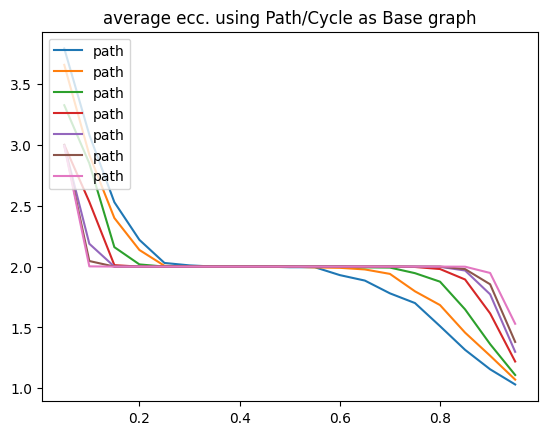

In [13]:
plt.figure()
plt.title("average ecc. using Path/Cycle as Base graph")
for N in [20,30,50,100,150,200,300]:
  Base_Path = nx.path_graph(N)
  avg_ecc_path = q_random_graph_q_sweep(N = N,Base_G=Base_Path)
  # Base_cycle = nx.cycle_graph(N)
  # avg_ecc_cycle = q_random_graph_q_sweep(N = N,Base_G=Base_cycle)

  plt.plot([i/100 for i in range(5,100,5)],avg_ecc_path,label = "path")
  # plt.xlabel("q")
  # plt.ylabel("e_q(G1)")
  # plt.plot([i/100 for i in range(5,100,5)],avg_ecc_cycle,"--",label = "cycle")
  # plt.xlabel("q")
  # plt.ylabel("e_q(G2)")
plt.legend(loc="upper left")
plt.show()